# 05 — Envelope Analysis (Square-Law Demodulation)
### Mục 1.3 (minh chứng ở mục 0.2) — Giải điều chế Envelope

**Mục đích**: minh chứng vì sao cần Envelope Analysis — tín hiệu thô/phổ
thô thường **không lộ rõ** BPFO/BPFI/BSF vì bị điều biên bởi cộng hưởng cơ
khí; phổ Envelope (sau khi giải điều chế) mới bộc lộ rõ các đỉnh này.

Công thức (đúng mục 1.3 của đề cương):

```
Envelope[n] = LowPassFilter( (x[n] * h_bandpass[n])² )
```

Notebook này cũng đối chiếu nhanh với Hilbert Transform để **kiểm tra
chéo hình dạng phổ** (không phải so sánh tài nguyên — việc đó thuộc
Giai đoạn 3, đo bằng số thật qua STM32Cube.AI/ST Edge AI Cloud).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from common import io_utils, pipeline, dsp, config as cfg
pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================== CẤU HÌNH ==============================
# Đổi USE_SYNTHETIC_DATA = False và chỉnh REAL_DATA_ROOT khi đã có dữ liệu
# CWRU thật. Xem README.md phần "Chuyển sang dữ liệu thật".
USE_SYNTHETIC_DATA = True
REAL_DATA_ROOT = Path("../../data/raw")            # <-- de_tai_nckh/data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False
# ========================================================================

In [3]:
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

> ⚠️ **Lưu ý dữ liệu giả lập**: khi `USE_SYNTHETIC_DATA = True`, mọi tín hiệu
> trong notebook này là **giả lập** (nhiễu + xung điều biên mô phỏng), chỉ để
> kiểm tra code chạy đúng và xem trước hình dạng đầu ra. **Không dùng số liệu
> giả lập này làm kết quả báo cáo chính thức.** Khi có dữ liệu CWRU thật, đổi
> `USE_SYNTHETIC_DATA = False` ở cell CẤU HÌNH và chạy lại toàn bộ notebook.

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 40


,file_path,load_hp,label,fault_diameter_mils,or_position,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,_data/synthetic_cwru/0hp/B_007.mat,0,B,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
1,_data/synthetic_cwru/0hp/B_014.mat,0,B,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
2,_data/synthetic_cwru/0hp/B_021.mat,0,B,21.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
3,_data/synthetic_cwru/0hp/IR_007.mat,0,IR,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
4,_data/synthetic_cwru/0hp/IR_014.mat,0,IR,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False


## Chọn dải bandpass

**Việc quan trọng nhất của notebook này**: `BAND_HZ` bên dưới là giá trị
**ví dụ**, cần chỉnh lại dựa trên quan sát thực tế ở notebook 03 (vùng tần
số có biên độ nổi bật nhất) kết hợp tài liệu kỹ thuật SKF 6205, theo đúng
quyết định ở mục 0.4 của đề cương — không dùng phương pháp dò tự động
(Kurtogram/Spectral Kurtosis).

In [5]:
FAULT_LABEL = "OR"
DIAMETER_MILS = 21
LOAD_HP = 0
BAND_HZ = (1500, 3500)     # <-- CHỈNH lại dựa trên quan sát phổ thật (notebook 03)
LP_CUTOFF_HZ = 500
FREQ_MAX_PLOT = 400

fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=LOAD_HP, diameter_mils=DIAMETER_MILS)
x = io_utils.load_de_signal(Path(fp))
rpm = cfg.NOMINAL_RPM_BY_LOAD[LOAD_HP]
print(f"File: {fp}")
print(f"RPM danh định: {rpm}")

File: _data/synthetic_cwru/0hp/OR_021_Centered.mat
RPM danh định: 1797


## Phổ Envelope (Square-Law) — đánh dấu BPFO/BPFI/BSF/FTF lý thuyết

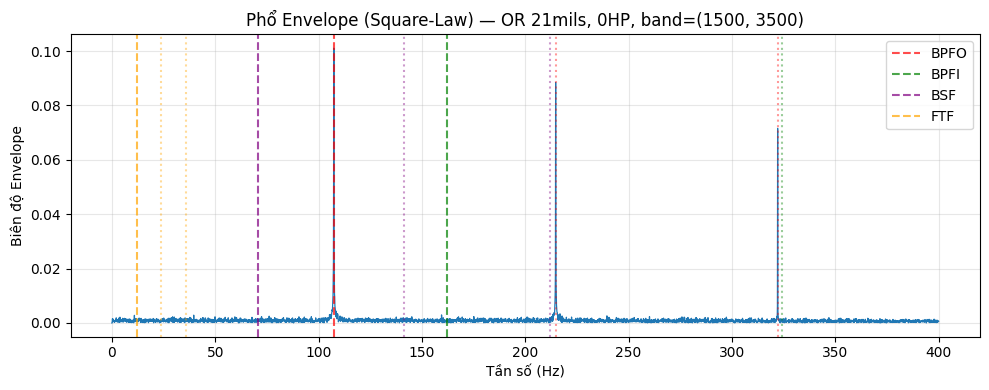

In [6]:
envelope = dsp.square_law_envelope(x, fs=12000, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
freqs, mag = dsp.compute_fft(envelope - envelope.mean(), fs=12000)
fault_freqs = cfg.bearing_fault_frequencies(rpm)

fig, ax = plt.subplots(figsize=(10, 4))
mask = freqs <= FREQ_MAX_PLOT
ax.plot(freqs[mask], mag[mask], linewidth=0.9)

colors = {"BPFO": "red", "BPFI": "green", "BSF": "purple", "FTF": "orange"}
for name, f in fault_freqs.items():
    if name == "f_rot" or f > FREQ_MAX_PLOT:
        continue
    ax.axvline(f, color=colors.get(name, "gray"), linestyle="--", alpha=0.7, label=name)
    for h in (2, 3):
        if f * h <= FREQ_MAX_PLOT:
            ax.axvline(f * h, color=colors.get(name, "gray"), linestyle=":", alpha=0.4)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ Envelope")
ax.set_title(f"Phổ Envelope (Square-Law) — {FAULT_LABEL} {DIAMETER_MILS}mils, {LOAD_HP}HP, band={BAND_HZ}")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_spectrum_square_law.png", dpi=150)
plt.show()

## Đối chiếu chéo với Hilbert Transform (chỉ kiểm tra hình dạng phổ)

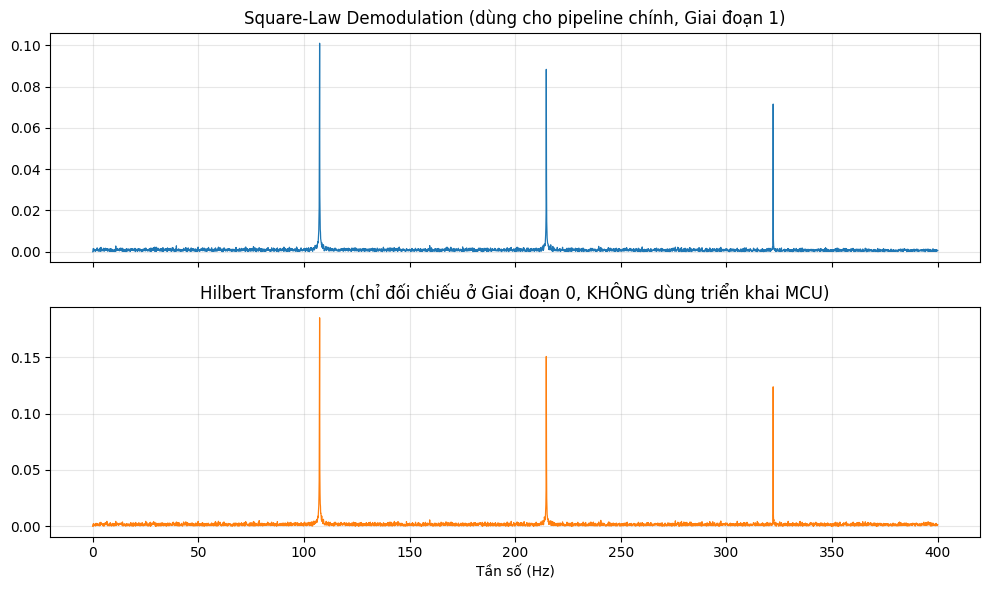

Kỳ vọng: 2 phổ có hình dạng TƯƠNG TỰ nhau (cùng vị trí đỉnh chính).
Nếu khác biệt rõ rệt, kiểm tra lại BAND_HZ hoặc bậc lọc trước khi chốt band.


In [7]:
envelope_hilbert = dsp.hilbert_envelope(x, fs=12000, band=BAND_HZ)
freqs_h, mag_h = dsp.compute_fft(envelope_hilbert - envelope_hilbert.mean(), fs=12000)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
mask = freqs <= FREQ_MAX_PLOT
axes[0].plot(freqs[mask], mag[mask], linewidth=0.9, color="tab:blue")
axes[0].set_title("Square-Law Demodulation (dùng cho pipeline chính, Giai đoạn 1)")
axes[0].grid(alpha=0.3)

mask_h = freqs_h <= FREQ_MAX_PLOT
axes[1].plot(freqs_h[mask_h], mag_h[mask_h], linewidth=0.9, color="tab:orange")
axes[1].set_title("Hilbert Transform (chỉ đối chiếu ở Giai đoạn 0, KHÔNG dùng triển khai MCU)")
axes[1].set_xlabel("Tần số (Hz)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_squarelaw_vs_hilbert.png", dpi=150)
plt.show()

print("Kỳ vọng: 2 phổ có hình dạng TƯƠNG TỰ nhau (cùng vị trí đỉnh chính).")
print("Nếu khác biệt rõ rệt, kiểm tra lại BAND_HZ hoặc bậc lọc trước khi chốt band.")

## Quan sát & quyết định

- Ghi lại `BAND_HZ` cuối cùng đã chốt và lý do (quan sát phổ + tài liệu
  SKF 6205) — đây là thông tin bắt buộc phải có trong báo cáo (mục 0.4).
- Xác nhận đỉnh BPFO/BPFI/BSF (tùy nhãn đang xét) lộ rõ hơn hẳn so với phổ
  thô ở notebook 03.

Hình đã lưu tại `outputs/figures/05_envelope_spectrum_square_law.png` và
`05_envelope_squarelaw_vs_hilbert.png`.